<a href="https://colab.research.google.com/github/keyonai/Practice-for-extern/blob/main/OCR_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.
Extracted Text (Without OCR):



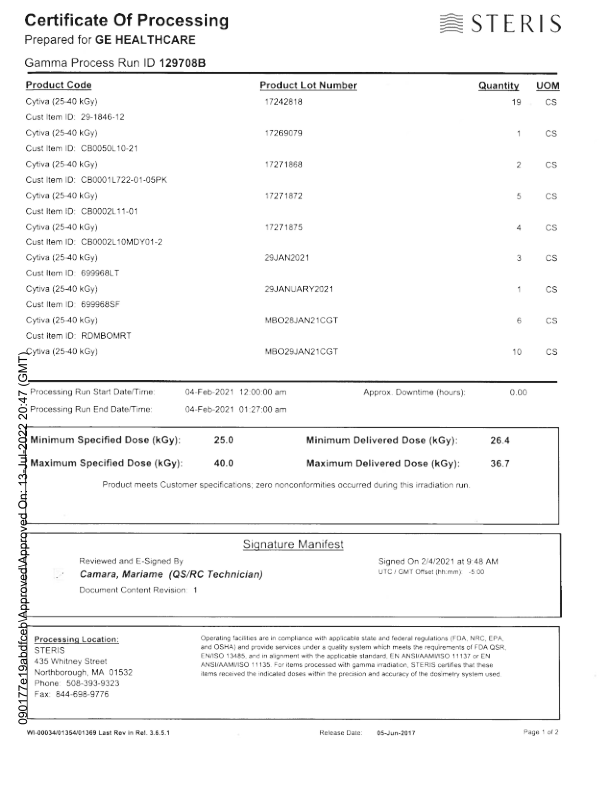

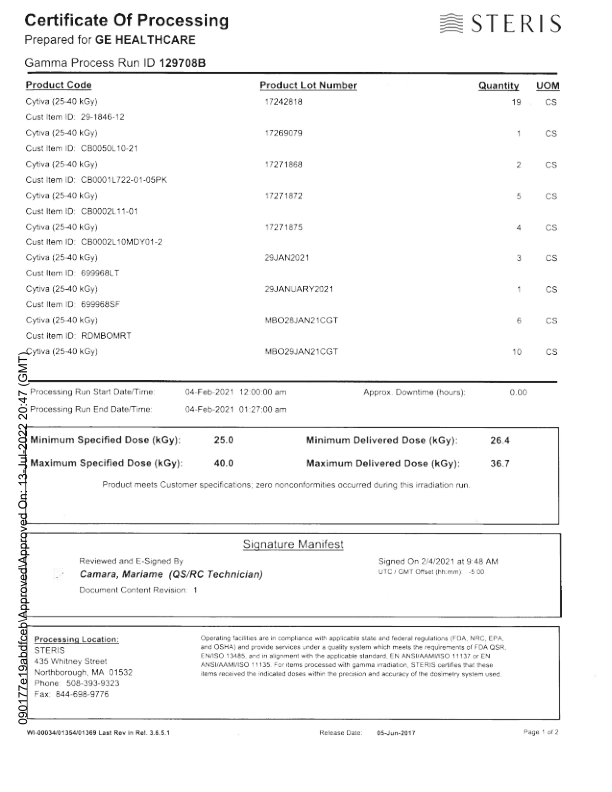

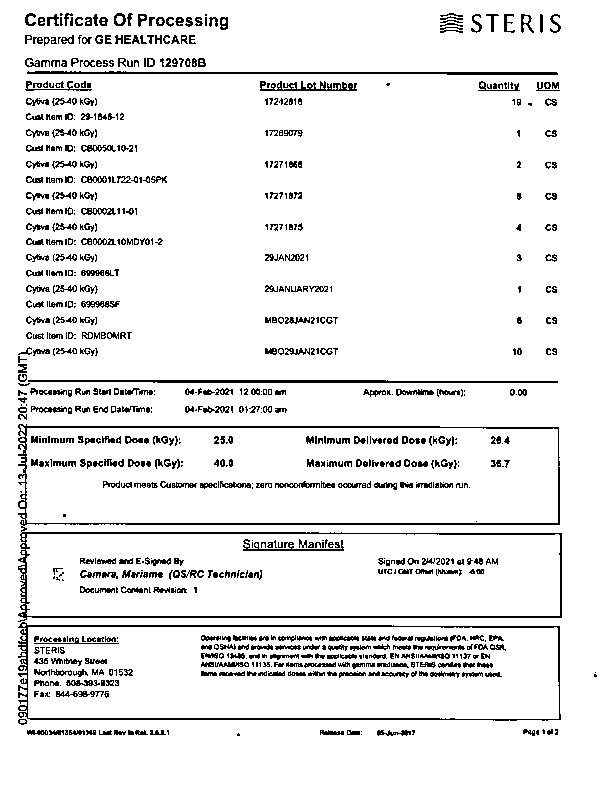

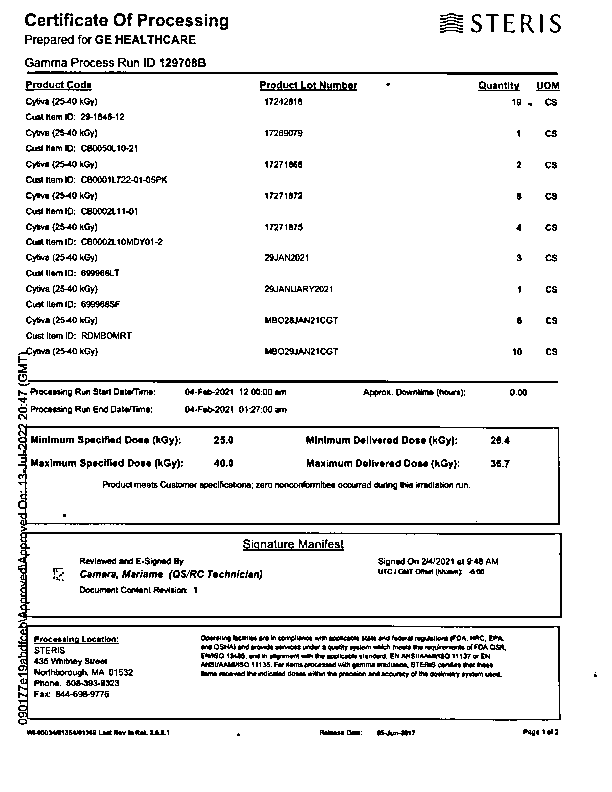

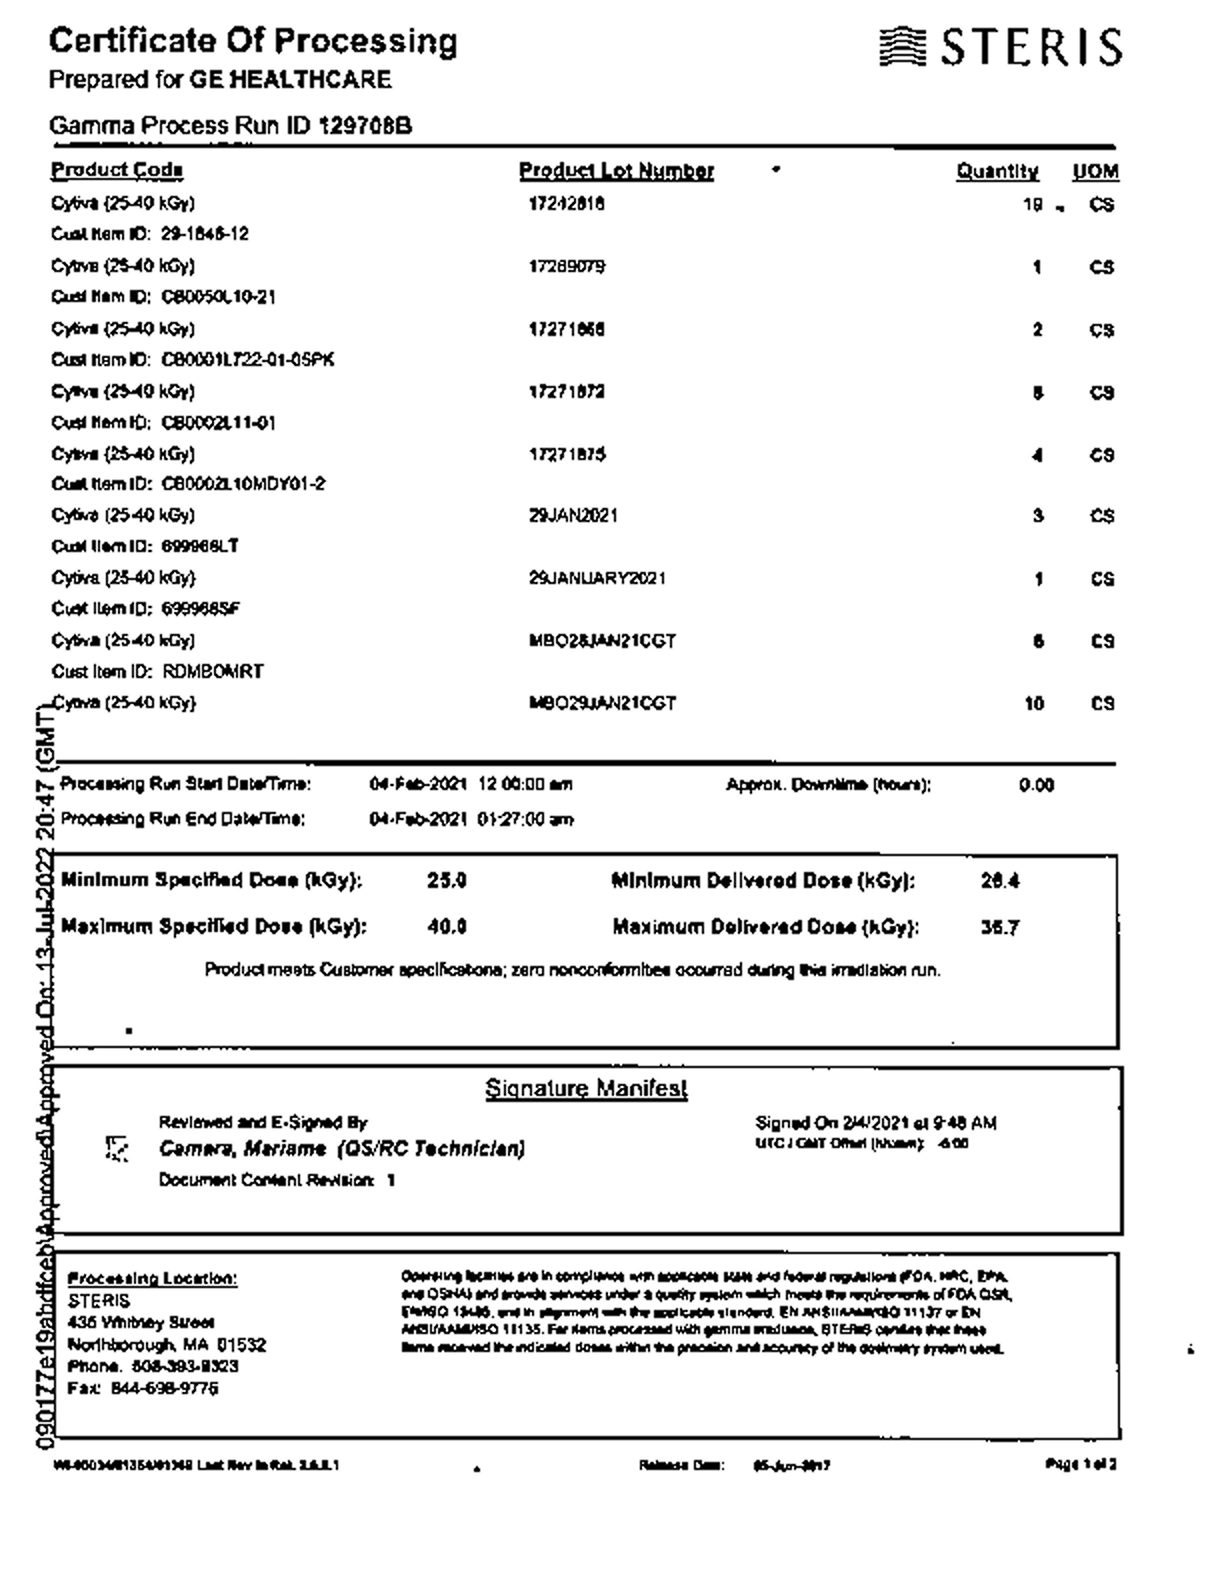

OCR Extracted Text:

Certificate Of Processing Z=STERIS
Prepared for GE HEALTHCARE

 

 

Gamma Process Run ID %29708B
Product Coda Product Lot Number 2 Quantity UOM
Cytva {25.40 kGy) 17242816 1.
Cust hem 1: 29-1846-12
Cytve (25-40 kGy) 17289079 1 ¢s
Card Kam 1D; CB00500 10-21
Cytive {25-40 kGy) 17271086 2 8
Cust tam IO: CQ0009L722-01-05PK
Cytva (25-40 kGy) wWer1074 8 8
Cust Memif; CB0002L11-01
Cyera (25-40 kGy) 417Q7 1875 4 69
Cust tem ID: C80002.10MDYO1-2
Cytive (25-40 kGy) 29JAN2021 3 6s
Cum emi: 699968LT
Cytira (23-40 kGy} 2QUANUARYZ2021 1 cS
Cust Ilo iD; 6989685
Cybra (25.40 kGy) MBO2BJANZICGT 6 ca
Cust Item ID: ROMBOMRT
pore (25-40 kGy} MBQZUANZICCT 1% 8 8©6cs
=
og;
5 Procanaing Run Stat DateTwne: 04-Feb-2021 12 00:00 an Appran. Downtime (towne); 9.00
§ Processing Run End DateTame: 04-Feb-2021 0127:00 an

Minimum Spacified Does (hGy): 25.9 Minimum Deliverod Dose (kGy): 26.4

3 Maximum Specified Dose (kGy): 40.0 Maximum Doliverad Cone {hGy}: 7

Product masts Customer apecificatona

In [2]:
#have to install tesseract
!apt install -y tesseract-ocr
!pip install pymupdf pytesseract opencv-python pillow numpy

import  cv2
import fitz
import numpy as np
import pytesseract
from PIL import Image
# Load the scanned PDF
pdf_path = "pharmaceutical-sdf-page4-certificate-processing.pdf"  # Update this path if needed
doc = fitz.open(pdf_path)

# Extract text from the first page using a standard method (this will fail for scanned PDFs)
page = doc[0]  # Get the first page
text = page.get_text("text")  # Try extracting text

print("Extracted Text (Without OCR):")
print(text)

 # Convert the first page to an image
pix = page.get_pixmap()
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

# Display the image
display(img)

# Convert the image to grayscale
img = np.array(img)  # Convert PIL image to NumPy array
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Display the grayscale image
display(Image.fromarray(gray))

# Apply adaptive thresholding to enhance contrast
gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# Display the processed image
display(Image.fromarray(gray))

# Apply Bilateral Filtering for noise reduction
gray = cv2.bilateralFilter(gray, 9, 75, 75)

# Display the processed image
display(Image.fromarray(gray))

# Resize image for better OCR accuracy
scale_percent = 200  # Increase image size by 200%
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)

# Display the resized image
display(Image.fromarray(gray))

# Run OCR on the preprocessed image
custom_config = r'--oem 3 -l eng'
ocr_text = pytesseract.image_to_string(gray, config=custom_config)

# Print extracted text
print("OCR Extracted Text:\n")
print(ocr_text)

# Remove excessive newlines and extra spaces
ocr_text = " ".join(ocr_text.split())
print("Cleaned OCR Text:\n", ocr_text)

import re

# Fix common OCR errors in pharmaceutical documents
ocr_text = re.sub(r'\bL0T\b', 'LOT', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bC0A\b', 'COA', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bCERT1FICATE\b', 'CERTIFICATE', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bEXP1RATION\b', 'EXPIRATION', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'[^a-zA-Z0-9\s,.%-]', '', ocr_text) # Remove unwanted symbols

print("Corrected OCR Text:\n", ocr_text)

